In [13]:
import seaborn as sns
import matplotlib.pyplot as plt
import pandas as pd

In [14]:
ib_cf = pd.read_csv("../results/ItemBasedCF_Results.csv")
ub_cf = pd.read_csv("../results/UserBasedCF_Results.csv")
svd = pd.read_csv("../results/SVD_Results.csv")

ib_cf["Model"] = "Item Based"
ub_cf["Model"] = "User Based"

df = pd.concat([ub_cf, ib_cf])
df.columns = ["Method", "MAE", "RMSE", "Model"]

In [15]:
df

,Method,MAE,RMSE,Model
0,Cosine,0.819977,1.083883,User Based
1,Pearson,0.843305,1.103354,User Based
0,Cosine,0.829645,1.102340,Item Based
1,Pearson,0.847555,1.117317,Item Based


Text(0.5, 1.0, 'MAE Errors - Item and User Based CF')

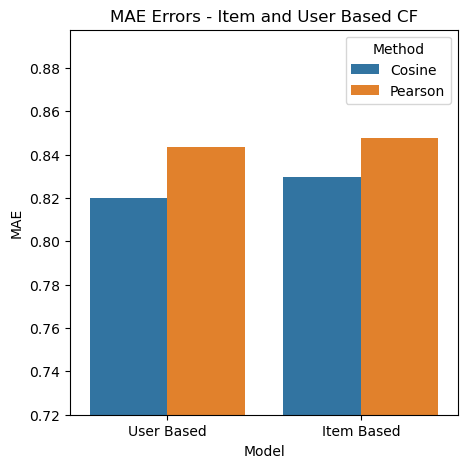

In [16]:
# Compare Rec Model for each method with MAE
fig, ax1 = plt.subplots(figsize=(5,5))
sns.barplot(df, x="Model", y="MAE", hue="Method", ax=ax1)
ax1.set_ylim(df["MAE"].min()-0.1, df["MAE"].max()+0.05)
ax1.set_title("MAE Errors - Item and User Based CF")

Text(0.5, 1.0, 'RMSE Errors - Item and User Based CF')

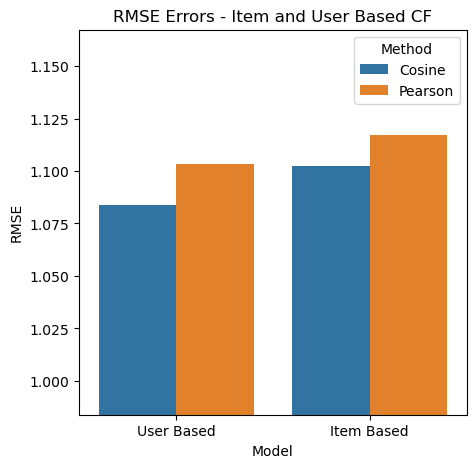

In [17]:
# Compare Rec Model for each method with RMSE
fig, ax2 = plt.subplots(figsize=(5,5))
sns.barplot(df, x="Model", y="RMSE", hue="Method", ax=ax2)
ax2.set_ylim(df["RMSE"].min()-0.1, df["RMSE"].max()+0.05)
ax2.set_title("RMSE Errors - Item and User Based CF")

Text(0.5, 1.0, 'SVD Errors')

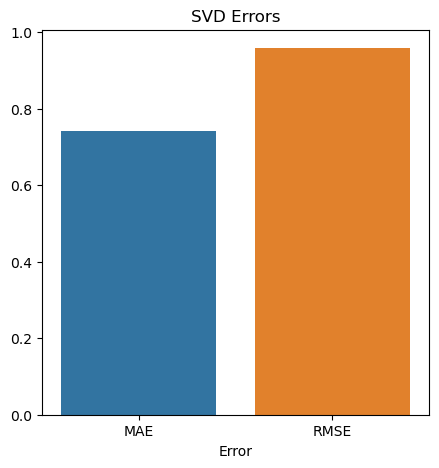

In [18]:
fig, ax3 = plt.subplots(figsize=(5,5))
sns.barplot(svd, ax=ax3)
ax3.set_xlabel("Error")
ax3.set_title("SVD Errors")

In [19]:
svd["Method"] = "SVD"
svd["Model"] = "SVD"

svd = svd[["Method", "MAE", "RMSE", "Model"]]

df_all = pd.concat([df, svd])
df_all

,Method,MAE,RMSE,Model
0,Cosine,0.819977,1.083883,User Based
1,Pearson,0.843305,1.103354,User Based
0,Cosine,0.829645,1.102340,Item Based
1,Pearson,0.847555,1.117317,Item Based
0,SVD,0.740633,0.958274,SVD


In [20]:
df_all.to_csv("../results/All_Results.csv", index=False)

In [27]:
df_all = df_all.reset_index(drop=True).sort_values("MAE", ascending=False)
df_all

,Method,MAE,RMSE,Model
3,Pearson,0.847555,1.117317,Item Based
1,Pearson,0.843305,1.103354,User Based
2,Cosine,0.829645,1.102340,Item Based
0,Cosine,0.819977,1.083883,User Based
4,SVD,0.740633,0.958274,SVD


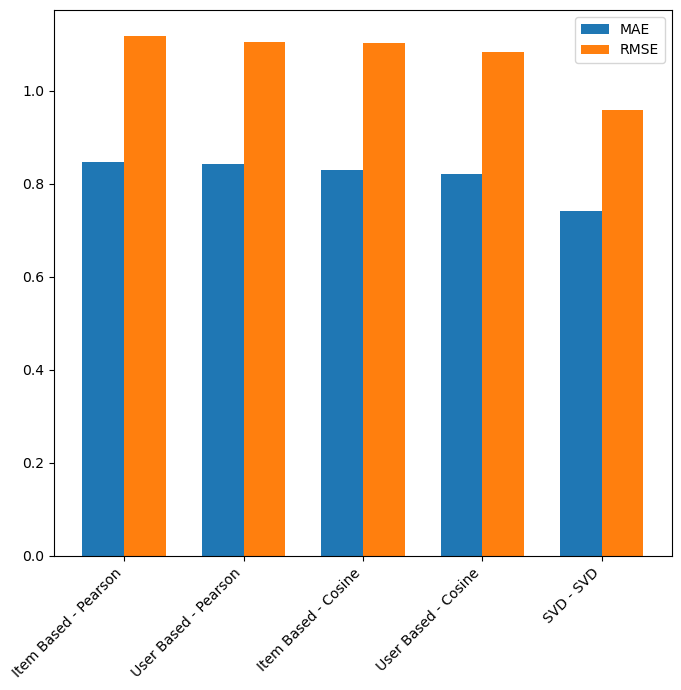

In [32]:
import numpy as np

plt.figure(figsize=(7,7))

x = np.arange(len(df_all))
width = 0.35

plt.bar(x - width/2, df_all["MAE"], width, label="MAE")
plt.bar(x + width/2, df_all["RMSE"], width, label="RMSE")

labels = df_all["Model"] + " - " + df_all["Method"]
plt.xticks(x, labels, rotation=45, ha="right")

plt.legend()
plt.tight_layout()
plt.show()

## Evaluation ##

SVD performs particularly well on this dataset, outperforming both item-based and user-based methods. This is likely due to the sparsity of the dataset and that the matrix decomposition involved with SVD handles it better than simple neighbor-focused algorithms. The sparsity makes it more difficult for neighbor-based algorithms (item-based and user-based) to find meaningful patterns and make effective recommendations.